# WFV Results Analysis

Aggregate JEPA and PPO walk-forward outputs across all windows.

This notebook loads:
- window manifest
- PPO test metrics per window
- PPO per-step action logs per window
- PPO validation evaluation logs (`evaluations.npz`)
- JEPA training logs per window


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

RUN_NAME = 'wfv_run1'
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = PROJECT_ROOT / 'logs' / 'wfv' / RUN_NAME
MANIFEST_PATH = LOG_DIR / f'{RUN_NAME}_windows.json'

assert LOG_DIR.exists(), f'Missing log dir: {LOG_DIR}'
assert MANIFEST_PATH.exists(), f'Missing manifest: {MANIFEST_PATH}'
PROJECT_ROOT, LOG_DIR, MANIFEST_PATH


(WindowsPath('c:/python/koulu/Gradu'),
 WindowsPath('c:/python/koulu/Gradu/logs/wfv/wfv_run1'),
 WindowsPath('c:/python/koulu/Gradu/logs/wfv/wfv_run1/wfv_run1_windows.json'))

In [2]:
with MANIFEST_PATH.open('r', encoding='utf-8') as f:
    manifest = json.load(f)

windows_df = pd.DataFrame(manifest['windows']).sort_values('window_index').reset_index(drop=True)
for col in ['train_start', 'train_end', 'val_end', 'test_end']:
    windows_df[col] = pd.to_datetime(windows_df[col], utc=True)

windows_df


,window,window_index,train_start,train_end,val_end,test_end,jepa_checkpoint,ppo_checkpoint
0,w000,0,2021-02-26 15:00:00+00:00,2024-02-25 23:59:59+00:00,2024-05-25 23:59:59+00:00,2024-08-25 23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w000/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w000/bes...
1,w001,1,2021-05-26 00:00:00+00:00,2024-05-25 23:59:59+00:00,2024-08-25 23:59:59+00:00,2024-11-25 23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w001/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w001/bes...
2,w002,2,2021-08-26 00:00:00+00:00,2024-08-25 23:59:59+00:00,2024-11-25 23:59:59+00:00,2025-02-25 23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w002/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w002/bes...
3,w003,3,2021-11-26 00:00:00+00:00,2024-11-25 23:59:59+00:00,2025-02-25 23:59:59+00:00,2025-05-25 23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w003/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w003/bes...
4,w004,4,2022-02-26 00:00:00+00:00,2025-02-25 23:59:59+00:00,2025-05-25 23:59:59+00:00,2025-08-25 23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w004/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w004/bes...
5,w005,5,2022-05-26 00:00:00+00:00,2025-05-25 23:59:59+00:00,2025-08-25 23:59:59+00:00,2025-11-25 23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w005/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w005/bes...


In [3]:
def load_window_artifacts(run_name: str, log_dir: Path, windows_df: pd.DataFrame):
    metrics_frames = []
    actions_frames = []
    eval_frames = []
    jepa_frames = []

    for row in windows_df.itertuples(index=False):
        window = row.window
        window_idx = int(row.window_index)

        metrics_path = log_dir / f'{run_name}_ppo_{window}_test_metrics.csv'
        actions_path = log_dir / f'{run_name}_ppo_{window}_test_actions.csv'
        eval_path = log_dir / f'{run_name}_ppo_{window}_eval' / 'evaluations.npz'
        jepa_log_path = log_dir / f'{run_name}_jepa_{window}_train_log.csv'

        if metrics_path.exists():
            df = pd.read_csv(metrics_path)
            df['window'] = window
            df['window_index'] = window_idx
            metrics_frames.append(df)

        if actions_path.exists():
            df = pd.read_csv(actions_path)
            df['window'] = window
            df['window_index'] = window_idx
            actions_frames.append(df)

        if eval_path.exists():
            npz = np.load(eval_path, allow_pickle=True)
            timesteps = np.asarray(npz['timesteps'])
            results = np.asarray(npz['results'])
            ep_lengths = np.asarray(npz['ep_lengths'])
            eval_df = pd.DataFrame({
                'timestep': timesteps,
                'eval_reward_mean': results.mean(axis=1),
                'eval_reward_median': np.median(results, axis=1),
                'eval_reward_std': results.std(axis=1),
                'eval_ep_length_mean': ep_lengths.mean(axis=1),
            })
            eval_df['window'] = window
            eval_df['window_index'] = window_idx
            eval_frames.append(eval_df)

        if jepa_log_path.exists():
            df = pd.read_csv(jepa_log_path)
            df['window'] = window
            df['window_index'] = window_idx
            jepa_frames.append(df)

    metrics_all = pd.concat(metrics_frames, ignore_index=True) if metrics_frames else pd.DataFrame()
    actions_all = pd.concat(actions_frames, ignore_index=True) if actions_frames else pd.DataFrame()
    eval_all = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
    jepa_all = pd.concat(jepa_frames, ignore_index=True) if jepa_frames else pd.DataFrame()
    return metrics_all, actions_all, eval_all, jepa_all

metrics_all, actions_all, eval_all, jepa_all = load_window_artifacts(RUN_NAME, LOG_DIR, windows_df)

print('metrics_all', metrics_all.shape)
print('actions_all', actions_all.shape)
print('eval_all', eval_all.shape)
print('jepa_all', jepa_all.shape)


metrics_all (198, 27)
actions_all (223068, 11)
eval_all (1000, 7)
jepa_all (500, 8)


In [4]:
window_summary = (metrics_all.groupby(['window_index', 'window'])
    .agg(
        assets=('asset_id', 'nunique'),
        total_return_mean=('total_return', 'mean'),
        total_return_median=('total_return', 'median'),
        sharpe_mean=('sharpe', 'mean'),
        max_drawdown_mean=('max_drawdown', 'mean'),
        turnover_mean=('avg_turnover', 'mean'),
        win_rate_mean=('win_rate', 'mean'),
        bh_total_return_mean=('bh_total_return', 'mean'),
    )
    .reset_index()
    .merge(windows_df[['window_index', 'window', 'train_start', 'train_end', 'val_end', 'test_end']], on=['window_index', 'window'], how='left')
)
window_summary


,window_index,window,assets,total_return_mean,total_return_median,sharpe_mean,max_drawdown_mean,turnover_mean,win_rate_mean,bh_total_return_mean,train_start,train_end,val_end,test_end
0,0,w000,33,0.063109,0.065804,1.207680,-0.109138,0.002258,0.504925,0.037720,2021-02-26 15:00:00+00:00,2024-02-25 23:59:59+00:00,2024-05-25 23:59:59+00:00,2024-08-25 23:59:59+00:00
1,1,w001,33,0.018901,-0.006409,0.203035,-0.099112,0.005558,0.492893,0.047845,2021-05-26 00:00:00+00:00,2024-05-25 23:59:59+00:00,2024-08-25 23:59:59+00:00,2024-11-25 23:59:59+00:00
2,2,w002,33,0.009203,0.003383,0.133550,-0.111474,0.014258,0.496160,0.018235,2021-08-26 00:00:00+00:00,2024-08-25 23:59:59+00:00,2024-11-25 23:59:59+00:00,2025-02-25 23:59:59+00:00
3,3,w003,33,-0.032323,-0.001170,-0.445203,-0.184850,0.010483,0.494932,-0.004003,2021-11-26 00:00:00+00:00,2024-11-25 23:59:59+00:00,2025-02-25 23:59:59+00:00,2025-05-25 23:59:59+00:00
4,4,w004,33,0.030996,0.013303,0.491085,-0.085011,0.015778,0.493726,0.071747,2022-02-26 00:00:00+00:00,2025-02-25 23:59:59+00:00,2025-05-25 23:59:59+00:00,2025-08-25 23:59:59+00:00
5,5,w005,33,-0.020750,-0.017617,-0.474712,-0.121098,0.012485,0.488283,0.007558,2022-05-26 00:00:00+00:00,2025-05-25 23:59:59+00:00,2025-08-25 23:59:59+00:00,2025-11-25 23:59:59+00:00


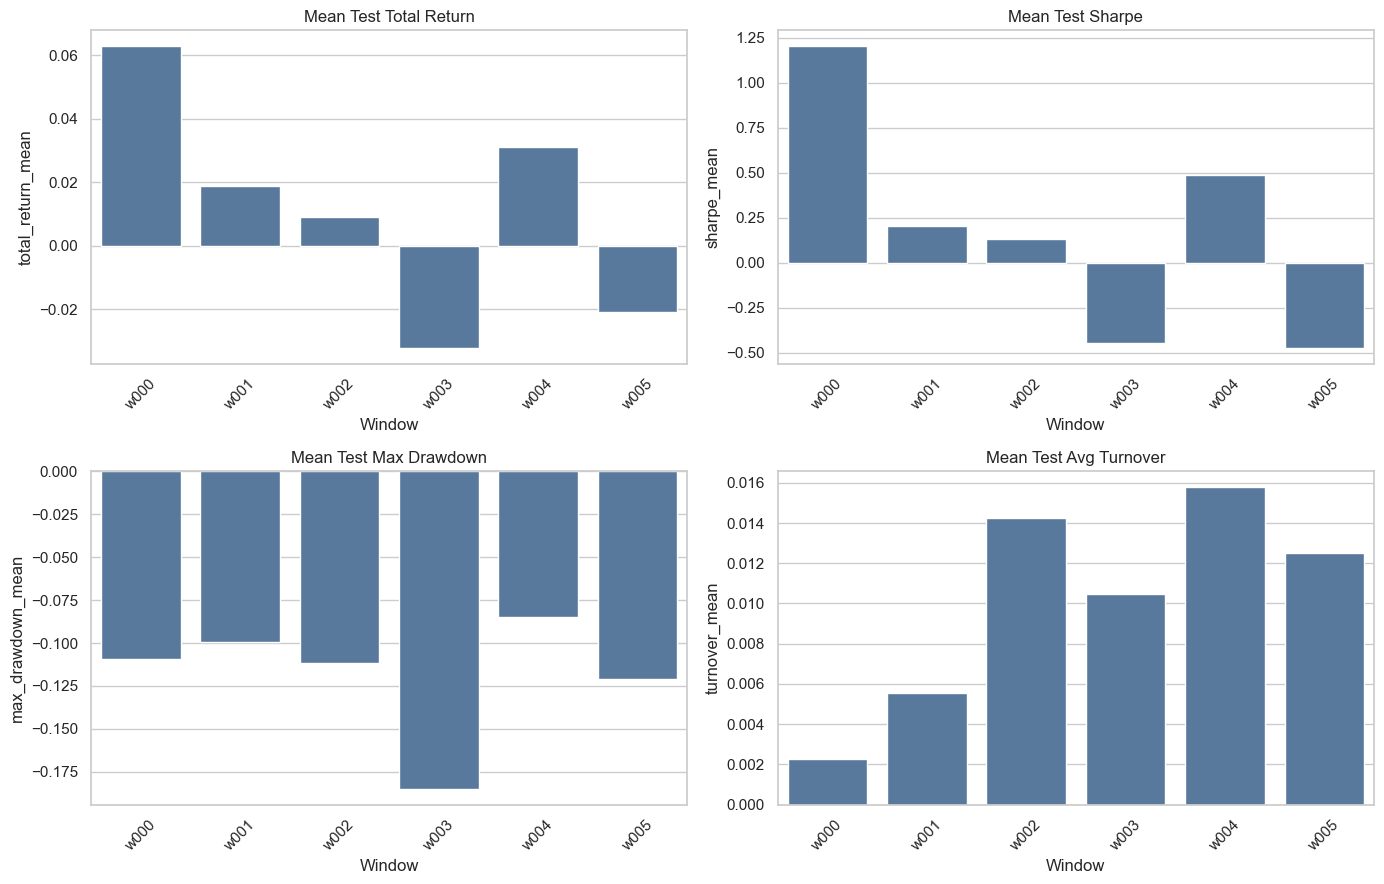

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_cols = [
    ('total_return_mean', 'Mean Test Total Return'),
    ('sharpe_mean', 'Mean Test Sharpe'),
    ('max_drawdown_mean', 'Mean Test Max Drawdown'),
    ('turnover_mean', 'Mean Test Avg Turnover'),
]
for ax, (col, title) in zip(axes.flatten(), plot_cols):
    sns.barplot(data=window_summary, x='window', y=col, ax=ax, color='#4C78A8')
    ax.set_title(title)
    ax.set_xlabel('Window')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


In [6]:
asset_summary = (metrics_all.groupby('asset_id')
    .agg(
        windows_seen=('window', 'nunique'),
        total_return_mean=('total_return', 'mean'),
        total_return_median=('total_return', 'median'),
        sharpe_mean=('sharpe', 'mean'),
        max_drawdown_mean=('max_drawdown', 'mean'),
        turnover_mean=('avg_turnover', 'mean'),
        trade_count_mean=('trade_count', 'mean'),
        bh_total_return_mean=('bh_total_return', 'mean'),
    )
    .sort_values('total_return_mean', ascending=False)
)
asset_summary


,windows_seen,total_return_mean,total_return_median,sharpe_mean,max_drawdown_mean,turnover_mean,trade_count_mean,bh_total_return_mean
asset_id,,,,,,,,
NVDA,6,0.111984,0.136842,1.066715,-0.221462,0.009270,9.000000,0.094419
GS,6,0.090664,0.109539,1.947786,-0.091701,0.009766,9.000000,0.084486
AAPL,6,0.075827,0.028410,1.501656,-0.097155,0.009862,9.166667,0.028024
SHW,6,0.063179,0.046165,1.400477,-0.086286,0.011606,10.666667,0.051851
MMM,6,0.059471,0.016255,0.690343,-0.097723,0.011890,11.666667,0.075925
WMT,6,0.053888,0.115545,1.065761,-0.090395,0.012411,12.833333,0.060308
TRV,6,0.051494,0.028541,0.918801,-0.087966,0.012245,12.166667,0.045945
JPM,6,0.046813,0.050303,1.363871,-0.090485,0.009277,8.666667,0.067172
IBM,6,0.046762,0.034322,0.973037,-0.125154,0.006789,6.666667,0.054273


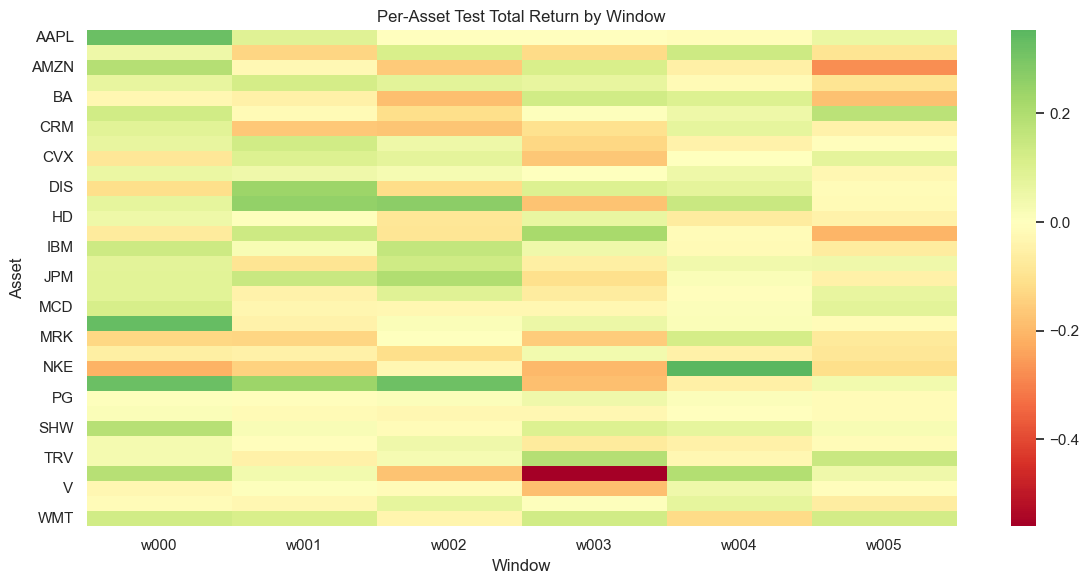

In [7]:
pivot_total_return = metrics_all.pivot_table(index='asset_id', columns='window', values='total_return')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_total_return, cmap='RdYlGn', center=0)
plt.title('Per-Asset Test Total Return by Window')
plt.xlabel('Window')
plt.ylabel('Asset')
plt.tight_layout()


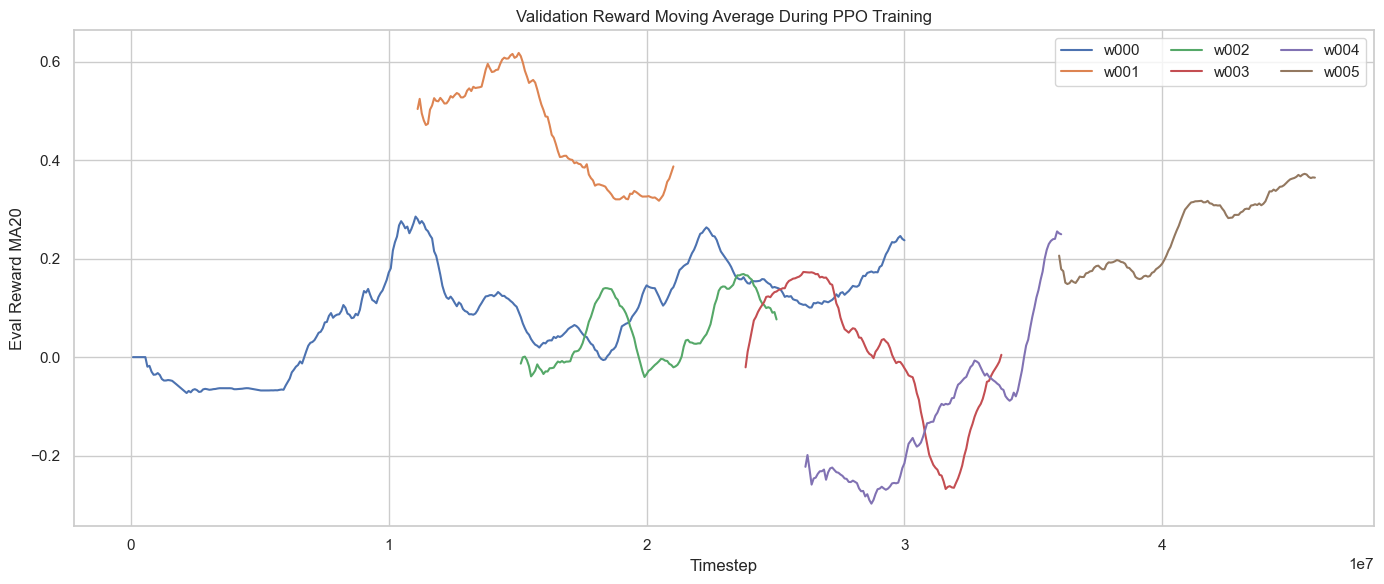

In [8]:
if not eval_all.empty:
    eval_plot = eval_all.copy()
    eval_plot['reward_ma20'] = eval_plot.groupby('window')['eval_reward_mean'].transform(lambda s: s.rolling(20, min_periods=1).mean())
    plt.figure(figsize=(14, 6))
    for window, dfw in eval_plot.groupby('window'):
        plt.plot(dfw['timestep'], dfw['reward_ma20'], label=window)
    plt.title('Validation Reward Moving Average During PPO Training')
    plt.xlabel('Timestep')
    plt.ylabel('Eval Reward MA20')
    plt.legend(ncol=3)
    plt.tight_layout()
else:
    print('No PPO eval logs found.')


In [9]:
if not jepa_all.empty:
    jepa_last = (jepa_all.sort_values(['window_index', 'epoch'])
        .groupby(['window_index', 'window'])
        .tail(1)
        [['window_index', 'window', 'epoch', 'train_loss', 'val_loss', 'train_cosine_similarity', 'train_std_ctx', 'train_std_tgt']]
        .sort_values('window_index')
    )
    jepa_last
else:
    print('No JEPA logs found.')


In [10]:
if not actions_all.empty:
    action_summary = (actions_all.groupby(['window_index', 'window'])
        .agg(
            n_rows=('step', 'size'),
            raw_action_mean=('raw_action', 'mean'),
            raw_action_std=('raw_action', 'std'),
            position_mean=('position', 'mean'),
            abs_position_mean=('position', lambda s: np.mean(np.abs(s))),
            turnover_mean=('turnover', 'mean'),
            reward_mean=('reward', 'mean'),
            wealth_last=('wealth', 'last'),
        )
        .reset_index()
    )
    action_summary
else:
    print('No action logs found.')


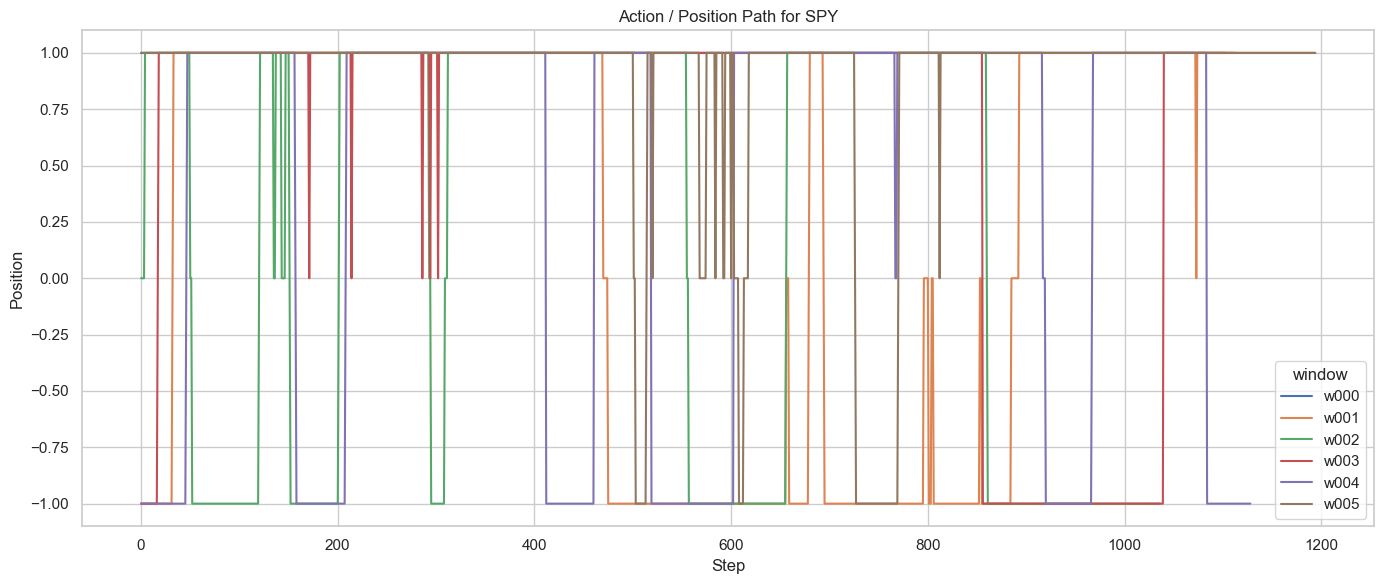

In [11]:
if not actions_all.empty:
    sample_asset = 'SPY' if 'SPY' in set(actions_all['asset_id']) else actions_all['asset_id'].iloc[0]
    sample = actions_all[actions_all['asset_id'] == sample_asset].copy()
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=sample, x='step', y='position', hue='window')
    plt.title(f'Action / Position Path for {sample_asset}')
    plt.xlabel('Step')
    plt.ylabel('Position')
    plt.tight_layout()
    sample.head()
else:
    print('No action logs found.')


In [12]:
overall_summary = pd.Series({
    'n_windows': windows_df['window'].nunique(),
    'n_assets_total': metrics_all['asset_id'].nunique() if not metrics_all.empty else 0,
    'mean_window_total_return': window_summary['total_return_mean'].mean() if not window_summary.empty else np.nan,
    'median_window_total_return': window_summary['total_return_mean'].median() if not window_summary.empty else np.nan,
    'mean_window_sharpe': window_summary['sharpe_mean'].mean() if not window_summary.empty else np.nan,
    'mean_asset_total_return': metrics_all['total_return'].mean() if not metrics_all.empty else np.nan,
    'median_asset_total_return': metrics_all['total_return'].median() if not metrics_all.empty else np.nan,
    'mean_asset_sharpe': metrics_all['sharpe'].mean() if not metrics_all.empty else np.nan,
    'mean_asset_max_drawdown': metrics_all['max_drawdown'].mean() if not metrics_all.empty else np.nan,
})
overall_summary


n_windows                      6.000000
n_assets_total                33.000000
mean_window_total_return       0.011523
median_window_total_return     0.014052
mean_window_sharpe             0.185906
mean_asset_total_return        0.011523
median_asset_total_return      0.004098
mean_asset_sharpe              0.185906
mean_asset_max_drawdown       -0.118447
dtype: float64